<a href="https://colab.research.google.com/github/Gowrav06/Data-Science/blob/main/Logistic_Regression_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data Handling
import pandas as pd
import numpy as np

In [2]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Model Building
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             classification_report, confusion_matrix)

In [4]:
# Preprocessing
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("diabetes (1).csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


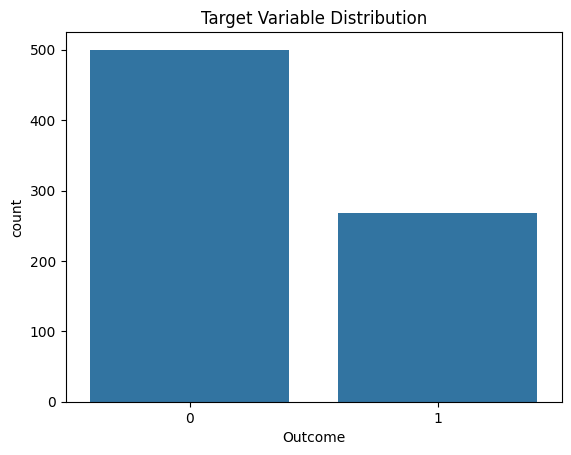

In [9]:
sns.countplot(x='Outcome', data=df)
plt.title("Target Variable Distribution")
plt.show()

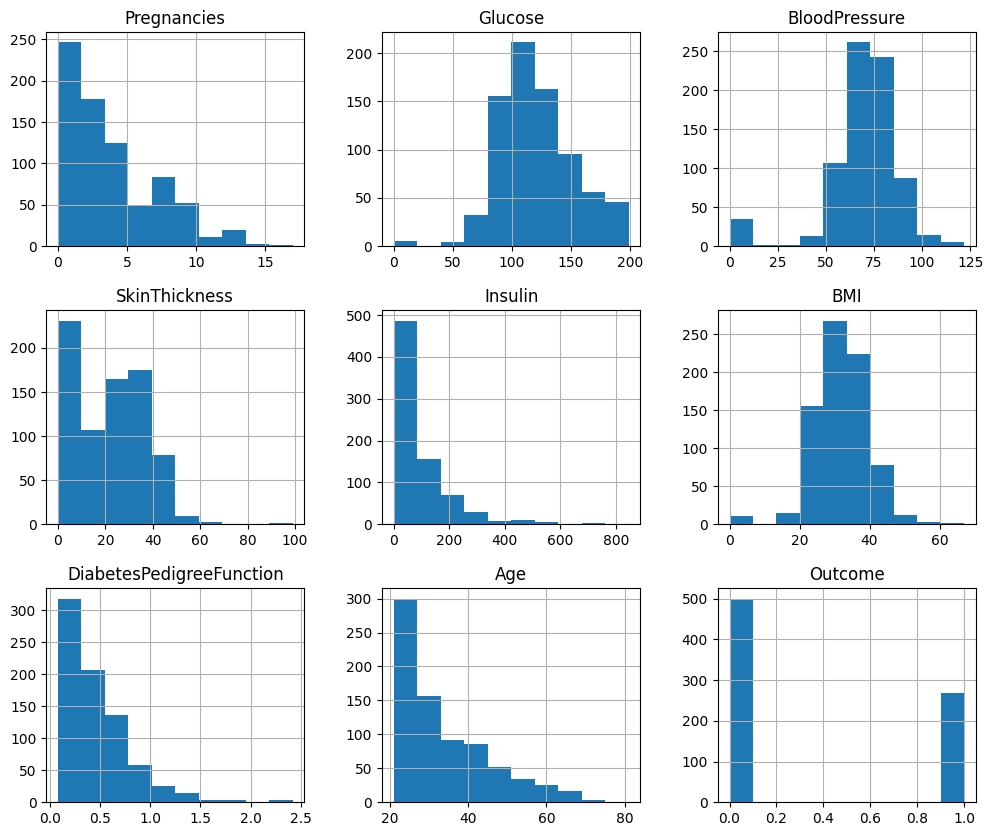

In [10]:
df.hist(figsize=(12,10))
plt.show()

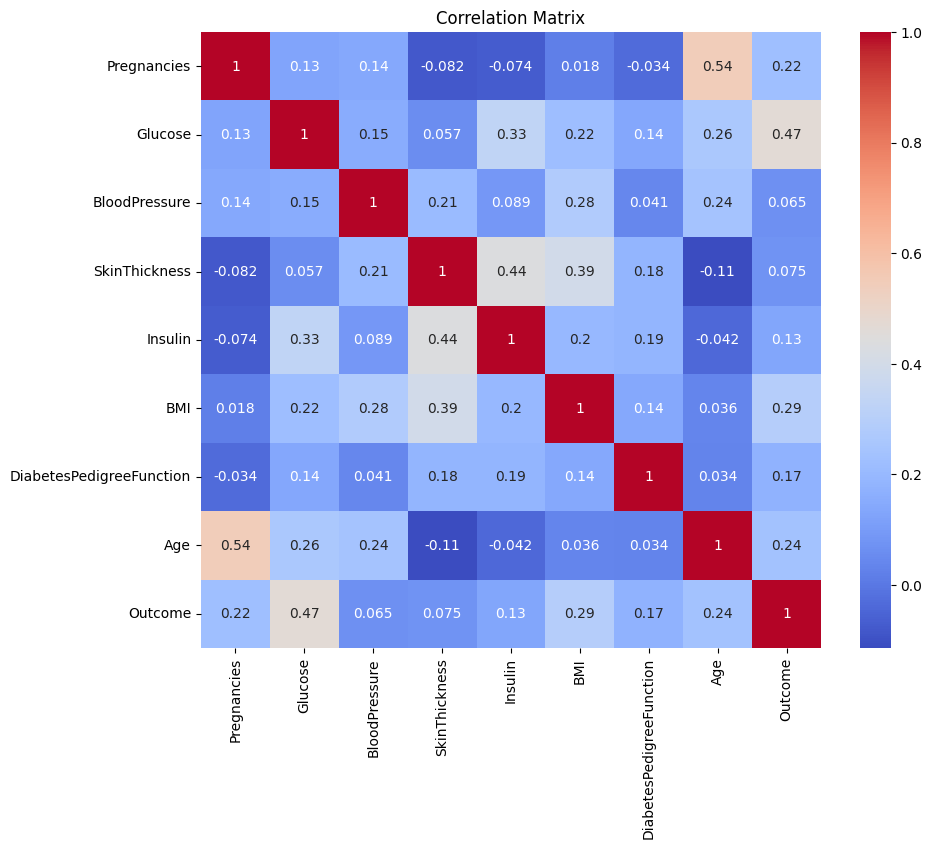

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [12]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    df[col] = df[col].replace(0, df[col].median())

In [13]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [16]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [17]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [18]:
accuracy_score(y_test, y_pred)

0.7662337662337663

In [19]:
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.6792452830188679
Recall: 0.6545454545454545
F1 Score: 0.6666666666666666


In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82        99
           1       0.68      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.77       154



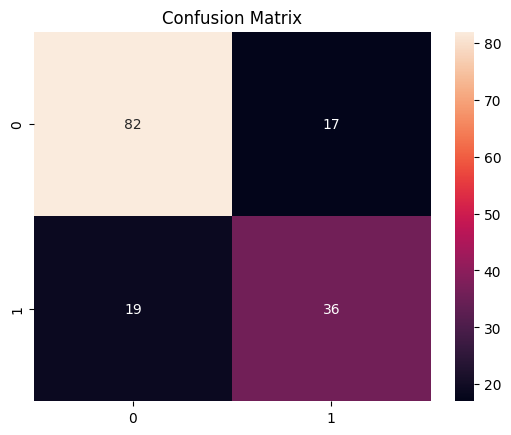

In [21]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [22]:
roc_auc_score(y_test, y_prob)

np.float64(0.8196510560146923)

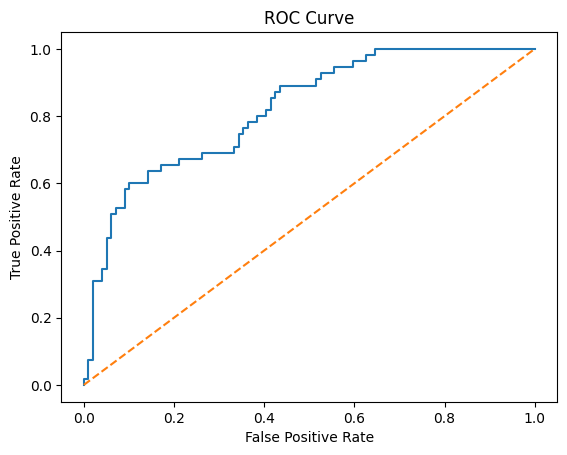

In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [24]:
cv_scores = cross_val_score(model, X_scaled, y, cv=5)
cv_scores.mean()

np.float64(0.7643663526016468)

In [25]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coeff_df.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
1,Glucose,1.150522
5,BMI,0.712522
7,Age,0.387256
0,Pregnancies,0.222140
6,DiabetesPedigreeFunction,0.213286
3,SkinThickness,0.051662
2,BloodPressure,-0.165550
4,Insulin,-0.222430


In [26]:
import pickle

pickle.dump(model, open("logistic_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [30]:
import streamlit as st
import pickle
import numpy as np

model = pickle.load(open("logistic_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

st.title("Diabetes Prediction App")

preg = st.number_input("Pregnancies")
glucose = st.number_input("Glucose")
bp = st.number_input("Blood Pressure")
bmi = st.number_input("BMI")
age = st.number_input("Age")

if st.button("Predict"):
    data = np.array([[preg, glucose, bp, 0, 0, bmi, 0, age]])
    data = scaler.transform(data)
    prediction = model.predict(data)

    if prediction == 1:
        st.error("Diabetic")
    else:
        st.success("Not Diabetic")

2026-03-07 06:01:37.730 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-07 06:01:37.732 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-07 06:01:37.734 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-07 06:01:37.734 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-07 06:01:37.735 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-07 06:01:37.736 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-07 06:01:37.737 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-07 06:01:37.737 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar